### AttentionWithSeq2Seq vs Seq2seq 

In [1]:
import sys
sys.path.append('C:/Users/KimDongyoung/Desktop/Github/my_git/mygit/DEEPLEARNING/밑바닥부터시작하는딥러닝2')
import numpy as np
import matplotlib.pyplot as plt
import sequence as sequence
from common.optimizer import Adam
from common.trainer import Trainer
from common.util import eval_seq2seq
from attention_seq2seq import AttentionSeq2seq
from ch07.seq2seq import Seq2seq
from ch07.peeky_seq2seq import PeekySeq2seq

In [2]:
# 데이터 읽기
(x_train, t_train), (x_test, t_test) = sequence.load_data('date.txt')
char_to_id, id_to_char = sequence.get_vocab()

# 입력 문장 반전
x_train, x_test = x_train[:, ::-1], x_test[:, ::-1]

In [3]:
x_train.shape

(45000, 29)

In [10]:
# 하이퍼파라미터 설정
vocab_size = len(char_to_id)
wordvec_size = 16
hidden_size = 256
batch_size = 128
max_epoch = 10
max_grad = 5.0

Training AttentionSeq2seq...
| 에폭 1 |  반복 1 / 351 | 시간 0[s] | 손실 4.08
| 에폭 1 |  반복 21 / 351 | 시간 8[s] | 손실 3.10
| 에폭 1 |  반복 41 / 351 | 시간 16[s] | 손실 1.88
| 에폭 1 |  반복 61 / 351 | 시간 25[s] | 손실 1.66
| 에폭 1 |  반복 81 / 351 | 시간 33[s] | 손실 1.33
| 에폭 1 |  반복 101 / 351 | 시간 43[s] | 손실 1.17
| 에폭 1 |  반복 121 / 351 | 시간 50[s] | 손실 1.13
| 에폭 1 |  반복 141 / 351 | 시간 58[s] | 손실 1.08
| 에폭 1 |  반복 161 / 351 | 시간 66[s] | 손실 1.05
| 에폭 1 |  반복 181 / 351 | 시간 74[s] | 손실 1.04
| 에폭 1 |  반복 201 / 351 | 시간 82[s] | 손실 1.03
| 에폭 1 |  반복 221 / 351 | 시간 90[s] | 손실 1.03
| 에폭 1 |  반복 241 / 351 | 시간 99[s] | 손실 1.02
| 에폭 1 |  반복 261 / 351 | 시간 107[s] | 손실 1.01
| 에폭 1 |  반복 281 / 351 | 시간 117[s] | 손실 1.01
| 에폭 1 |  반복 301 / 351 | 시간 128[s] | 손실 1.00
| 에폭 1 |  반복 321 / 351 | 시간 136[s] | 손실 1.00
| 에폭 1 |  반복 341 / 351 | 시간 146[s] | 손실 0.99
Q 10/15/94                     
T 1994-10-15
X 1988-08-21
---
Q thursday, november 13, 2008  
T 2008-11-13
X 1981-08-21
---
Q Mar 25, 2003                 
T 2003-03-25
X 1988-08-21


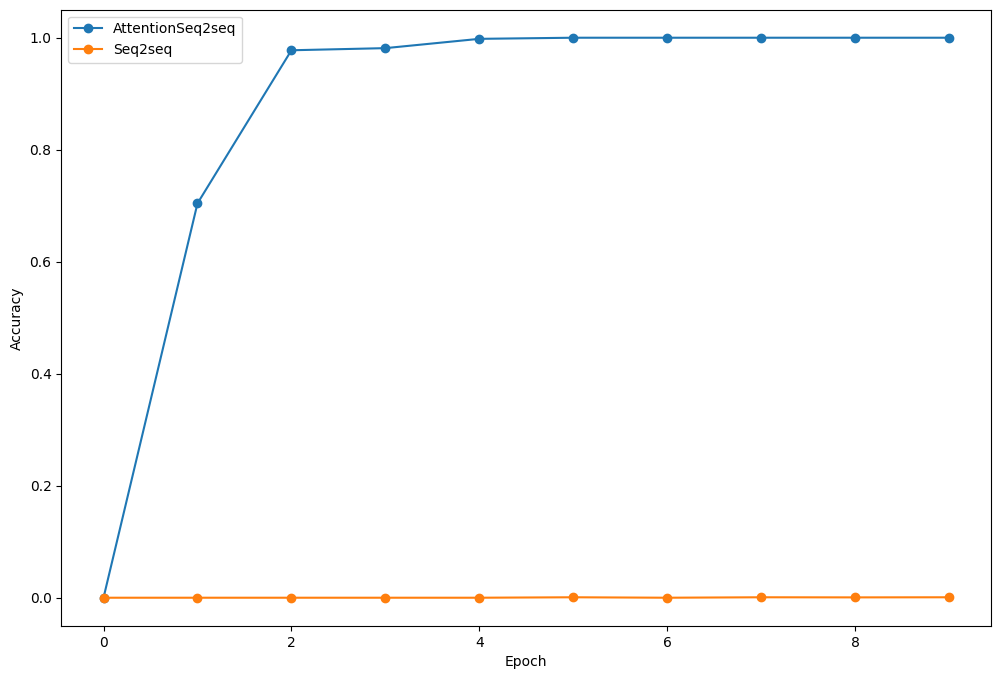

In [11]:
# 모델 리스트
models = {
    "AttentionSeq2seq": AttentionSeq2seq(vocab_size, wordvec_size, hidden_size),
    "Seq2seq": Seq2seq(vocab_size, wordvec_size, hidden_size),
    #"PeekySeq2seq": PeekySeq2seq(vocab_size, wordvec_size, hidden_size)
}

results = {}

for model_name, model in models.items():
    print(f"Training {model_name}...")
    optimizer = Adam()
    trainer = Trainer(model, optimizer)

    acc_list = []
    for epoch in range(max_epoch):
        trainer.fit(x_train, t_train, max_epoch=1,
                    batch_size=batch_size, max_grad=max_grad)

        correct_num = 0
        for i in range(len(x_test)):
            question, correct = x_test[[i]], t_test[[i]]
            verbose = i < 10
            correct_num += eval_seq2seq(model, question, correct,
                                        id_to_char, verbose, is_reverse=True)

        acc = float(correct_num) / len(x_test)
        acc_list.append(acc)
        print(f'{model_name} Accuracy %.3f%%' % (acc * 100))

    results[model_name] = acc_list
    model.save_params()

# 그래프 그리기
plt.figure(figsize=(12, 8))
for model_name, acc_list in results.items():
    x = np.arange(len(acc_list))
    plt.plot(x, acc_list, marker='o', label=model_name)

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim(-0.05, 1.05)
plt.legend()
plt.show()